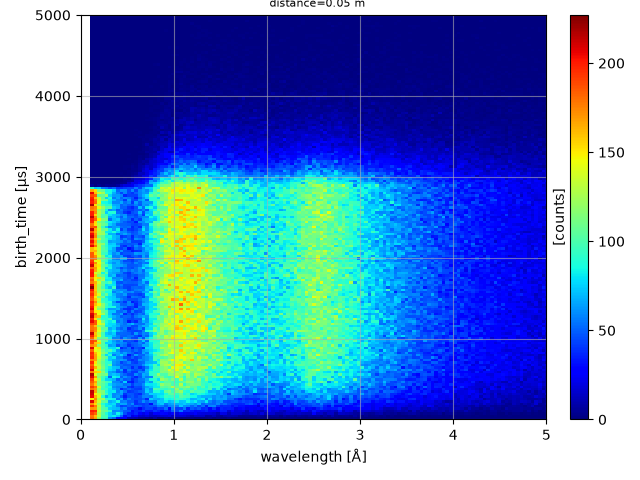

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import scipp as sc
import tof

source = tof.Source(facility="ess-trex", neutrons=1_000_000)
da = source.data.squeeze()

fig, ax = plt.subplots()
p = da.hist(birth_time=200, wavelength=500).plot(cmap="jet", ax=ax)
ax.set_title(str(source), fontsize=8)
ax.set_xlim([0, 5])
ax.set_ylim([0, 5000])
ax.grid(alpha=0.6)

In [2]:
%matplotlib widget
source = tof.Source(facility="ess-trex", neutrons=500_000)
source.plot()


InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [3]:
from drtrex.components.source import Source
from drtrex.instrument import Instrument

central_wavelength = sc.scalar(1.5, unit="Å")
rrm: int = 8  # repetition rate multiplication factor
T_OFFSET = sc.scalar(1.7, unit="ms")
trex = Instrument(wavelength=central_wavelength, rrm=rrm, t_offset=T_OFFSET)
mask = trex.mask_from_choppers("Monochromatic Chopper 2")
# mask = trex.mask_from_chopper("Bandwidth Chopper 2")

source = Source(facility="ess", neutrons=1_000_000)
source.apply_mask(mask)
print(source.data)

ModuleNotFoundError: No module named 'drtrex'

In [ ]:
flux = trex.estimate_flux()
flux

<scipp.Variable> (rrm: 7)      int64         [counts]  [190, 835, ..., 516, 212]

In [ ]:
import tof
import scipp as sc
import plopp as pp

instruments = ["cspec", "bifrost", "miracles", "trex", "vespa", "tbl"]

histograms = {}
wavelength_bins = sc.linspace(
    start=0, stop=4.0, num=100, unit="angstrom", dim="wavelength"
)
for inst in instruments:
    src = tof.Source(facility=f"ess-{inst}")
    histograms[inst] = src.data.hist(wavelength=wavelength_bins)


plot = pp.plot(histograms, grid=True, title="ESS sources", figsize=(10, 5))
plot.ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.05), ncol=5)
plot

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…